<a href="https://colab.research.google.com/github/Oyushbeta0413/2025AppChallenge/blob/main/GARSEF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_4403/1442188559.py:129: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


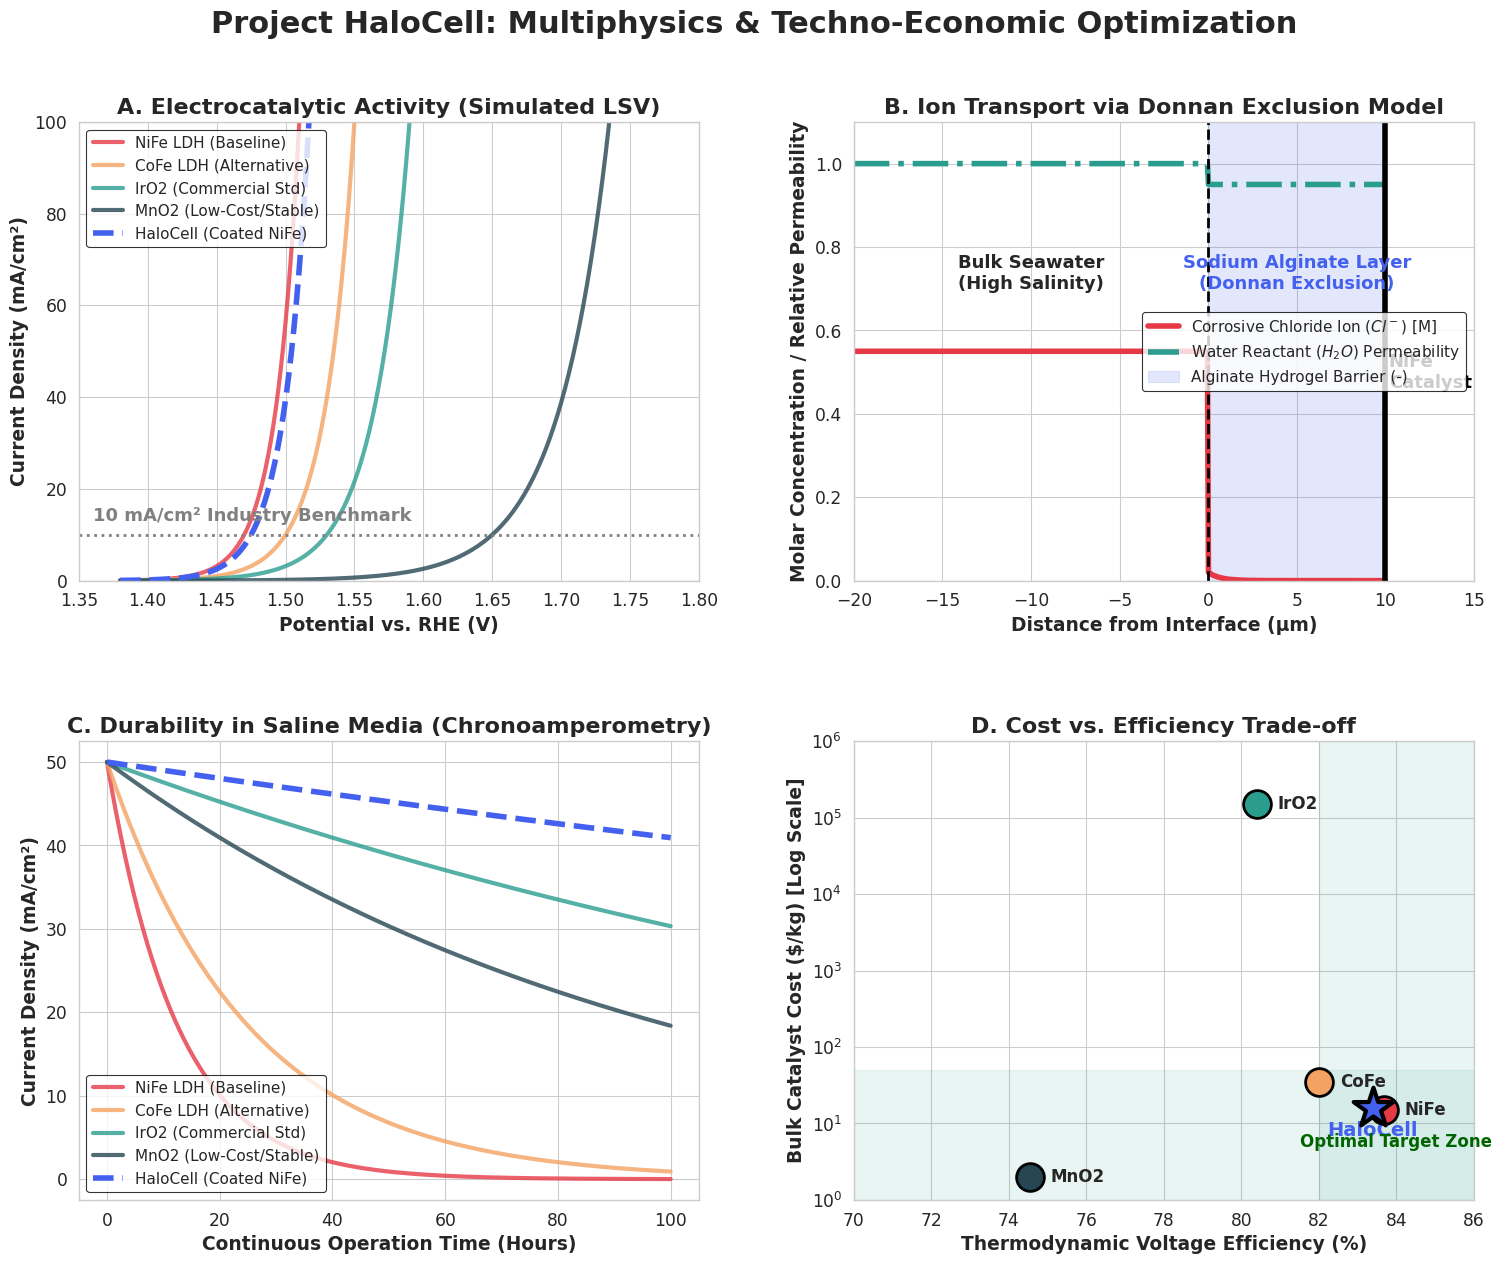

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns

# =========================================================================
# SYSTEM SETUP: Publication-quality styling (ISEF Standard)
# =========================================================================
sns.set_theme(style="whitegrid", context="paper", font_scale=1.4)

# Data Dictionary: {Name: [Overpotential (V), Tafel Slope, Cost ($/kg), Decay Rate, Color]}
catalysts = {
    "NiFe LDH (Baseline)":      {"eta_10": 0.240, "b": 0.040, "cost": 15, "decay": 0.08, "color": "#E63946"},
    "CoFe LDH (Alternative)":   {"eta_10": 0.270, "b": 0.050, "cost": 35, "decay": 0.04, "color": "#F4A261"},
    "IrO2 (Commercial Std)":    {"eta_10": 0.300, "b": 0.060, "cost": 150000, "decay": 0.005, "color": "#2A9D8F"},
    "MnO2 (Low-Cost/Stable)":   {"eta_10": 0.420, "b": 0.085, "cost": 2, "decay": 0.01, "color": "#264653"}
}

# HaloCell engineered parameters (Slight Ohmic resistance added from polymer, massively improved stability)
halocell = {"HaloCell (Alginate-NiFe)": {"eta_10": 0.245, "b": 0.042, "cost": 16, "decay": 0.002, "color": "#4361EE"}}

fig = plt.figure(figsize=(18, 14))
gs = GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.25)
fig.suptitle("Project HaloCell: Multiphysics & Techno-Economic Optimization", fontsize=22, fontweight='bold', y=0.96)

# =========================================================================
# PANEL A: Polarization Curves (Butler-Volmer Kinetics)
# =========================================================================
ax1 = fig.add_subplot(gs[0, 0])
eta_range = np.linspace(0.15, 0.60, 500)

for name, params in catalysts.items():
    j = 10 * (10 ** ((eta_range - params["eta_10"]) / params["b"]))
    ax1.plot(1.23 + eta_range, j, label=name, color=params["color"], linewidth=3, alpha=0.8)

h_params = halocell["HaloCell (Alginate-NiFe)"]
j_halo = 10 * (10 ** ((eta_range - h_params["eta_10"]) / h_params["b"]))
ax1.plot(1.23 + eta_range, j_halo, label="HaloCell (Coated NiFe)", color=h_params["color"], linewidth=4, linestyle='--')

ax1.axhline(y=10, color='gray', linestyle=':', linewidth=2)
ax1.text(1.36, 13, "10 mA/cm² Industry Benchmark", color='gray', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_xlim(1.35, 1.80)
ax1.set_xlabel("Potential vs. RHE (V)", fontweight='bold')
ax1.set_ylabel("Current Density (mA/cm²)", fontweight='bold')
ax1.set_title("A. Electrocatalytic Activity (Simulated LSV)", fontweight='bold', fontsize=16)
ax1.legend(loc="upper left", fontsize=11, frameon=True, edgecolor='black')

# =========================================================================
# PANEL B: Donnan Exclusion Multiphysics (Ion Transport)
# =========================================================================
ax2 = fig.add_subplot(gs[0, 1])
x = np.linspace(-20, 10, 500) # Distance from bulk seawater to catalyst (micrometers)

# Simulate Chloride [Cl-] concentration profile crashing at polymer interface (x=0)
cl_conc = np.piecewise(x, [x < 0, x >= 0], [0.55, lambda x: 0.02 * np.exp(-1.5 * x)])
# Simulate Water Permeability staying high
h2o_conc = np.piecewise(x, [x < 0, x >= 0], [1.0, 0.95])

ax2.plot(x, cl_conc, color="#E63946", linewidth=4, label="Corrosive Chloride Ion ($Cl^-$) [M]")
ax2.plot(x, h2o_conc, color="#2A9D8F", linewidth=4, linestyle="-.", label="Water Reactant ($H_2O$) Permeability")

# Shading for polymer layer
ax2.axvspan(0, 10, color='#4361EE', alpha=0.15, label="Alginate Hydrogel Barrier (-)")
ax2.axvline(0, color='black', linewidth=2, linestyle='--')
ax2.axvline(10, color='black', linewidth=4)

ax2.text(-10, 0.7, "Bulk Seawater\n(High Salinity)", ha='center', fontsize=13, fontweight='bold')
ax2.text(5, 0.7, "Sodium Alginate Layer\n(Donnan Exclusion)", ha='center', fontsize=13, fontweight='bold', color='#4361EE')
ax2.text(10.2, 0.5, "NiFe\nCatalyst", va='center', fontsize=13, fontweight='bold', color='black')

ax2.set_xlim(-20, 15)
ax2.set_ylim(0, 1.1)
ax2.set_xlabel("Distance from Interface (μm)", fontweight='bold')
ax2.set_ylabel("Molar Concentration / Relative Permeability", fontweight='bold')
ax2.set_title("B. Ion Transport via Donnan Exclusion Model", fontweight='bold', fontsize=16)
ax2.legend(loc="center right", fontsize=11, frameon=True, edgecolor='black')

# =========================================================================
# PANEL C: Simulated Durability (Chronoamperometry in Seawater)
# =========================================================================
ax3 = fig.add_subplot(gs[1, 0])
time_hours = np.linspace(0, 100, 500) # 100 hour continuous stress test

# Decay formula: j(t) = j_initial * e^(-lambda * t)
for name, params in catalysts.items():
    j_t = 50 * np.exp(-params["decay"] * time_hours) # Start at high current (50 mA/cm2)
    ax3.plot(time_hours, j_t, label=name, color=params["color"], linewidth=3, alpha=0.8)

# HaloCell Durability
j_t_halo = 50 * np.exp(-h_params["decay"] * time_hours)
ax3.plot(time_hours, j_t_halo, label="HaloCell (Coated NiFe)", color=h_params["color"], linewidth=4, linestyle='--')

ax3.set_xlabel("Continuous Operation Time (Hours)", fontweight='bold')
ax3.set_ylabel("Current Density (mA/cm²)", fontweight='bold')
ax3.set_title("C. Durability in Saline Media (Chronoamperometry)", fontweight='bold', fontsize=16)
ax3.legend(loc="lower left", fontsize=11, frameon=True, edgecolor='black')

# =========================================================================
# PANEL D: Techno-Economic Optimization Matrix
# =========================================================================
ax4 = fig.add_subplot(gs[1, 1])
all_entities = {**catalysts, **halocell}

for name, params in all_entities.items():
    eff = (1.23 / (1.23 + params["eta_10"])) * 100 # Voltage Efficiency
    cost = params["cost"]

    if "HaloCell" in name:
        ax4.scatter(eff, cost, s=900, color=params["color"], edgecolor='black', linewidth=3, zorder=5, marker='*')
        ax4.annotate("HaloCell", (eff, cost), xytext=(0, -20), textcoords="offset points", ha='center', fontweight='bold', fontsize=14, color=params["color"])
    else:
        ax4.scatter(eff, cost, s=400, color=params["color"], edgecolor='black', linewidth=2, zorder=4)
        ax4.annotate(name.split(" ")[0], (eff, cost), xytext=(15, 0), textcoords="offset points", va='center', fontweight='bold', fontsize=12)

ax4.set_yscale('log') # IrO2 is astronomically expensive, requiring a log scale
ax4.set_xlim(70, 86)
ax4.set_ylim(1, 1000000)

ax4.set_xlabel("Thermodynamic Voltage Efficiency (%)", fontweight='bold')
ax4.set_ylabel("Bulk Catalyst Cost ($/kg) [Log Scale]", fontweight='bold')
ax4.set_title("D. Cost vs. Efficiency Trade-off", fontweight='bold', fontsize=16)

# Highlight "Optimal Zone"
ax4.axvspan(82, 86, color='#2A9D8F', alpha=0.1, zorder=1)
ax4.axhspan(1, 50, color='#2A9D8F', alpha=0.1, zorder=1)
ax4.text(84, 5, "Optimal Target Zone", color='darkgreen', fontweight='bold', ha='center', fontsize=12)

plt.tight_layout()
plt.show()